In [1]:
import numpy as np
import pickle
import scipy.io as sio
import matplotlib.pyplot as plt
from nilearn.image import new_img_like
import pandas as pd
import nibabel as nib
import seaborn as sns
from nilearn import plotting
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.rdm import RDMs
from glob import glob
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight

In [2]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [3]:
import matplotlib.colors
def RDMcolormapObject(direction=1):
    """
    Returns a matplotlib color map object for RSA and brain plotting
    """
    if direction == 0:
        cs = ['yellow', 'red', 'gray', 'turquoise', 'blue']
    elif direction == 1:
        cs = ['blue', 'turquoise', 'gray', 'red', 'yellow']
    else:
        raise ValueError('Direction needs to be 0 or 1')
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", cs)
    return cmap

In [73]:
image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'
# load one image to get the dimensions and make the mask
tmp_img = nib.load(image_path)

## 0. Load fMRI RDMs

In [20]:
# image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'
# # load one image to get the dimensions and make the mask
# tmp_img = nib.load(image_path)
# # we infer the mask by looking at non-nan voxels
# mask = ~np.isnan(tmp_img.get_fdata())
# x, y, z = tmp_img.get_fdata().shape
# centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

Finding searchlights...: 100%|██████████| 64544/64544 [00:28<00:00, 2291.32it/s]


Found 61997 searchlights


### Stimuli

In [6]:
# stim_file = pd.read_csv('../IAPS_fMRI_RSA/fmri_conditions_trial_ordered.csv')
# stim_Nt = stim_file[0:100]
# stim_Pl = stim_file[100:200].reset_index()
# stim_Up = stim_file[200:300].reset_index()

In [7]:
# stim_Nt_id = pd.DataFrame(stim_Nt[['stim_order']]).T
# stim_Nt_id.shape
# stim_Pl_id = pd.DataFrame(stim_Pl[['stim_order']]).T
# stim_Pl_id.shape
# stim_Up_id = pd.DataFrame(stim_Up[['stim_order']]).T
# stim_Up_id.shape
# print("Netrual    Type: {} Shape/Length: {}".format(type(stim_Nt_id), stim_Nt_id.shape))
# print("Pleasant   Type: {} Shape/Length: {}".format(type(stim_Pl_id), stim_Pl_id.shape))
# print("Unpleasant Type: {} Shape/Length: {}".format(type(stim_Up_id), stim_Up_id.shape))

Netrual    Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Pleasant   Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Unpleasant Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)


In [8]:
# sub_avg = []

# subjects = 20
# for i in range(subjects):
#     cond_all = []
#     cond_avg = []
#     #Pleasant
#     mat_name_Pl = '../IAPS_fMRI_RSA/fMRI/Pl{}.mat'.format(i+1)
#     mat_file_Pl = sio.loadmat(mat_name_Pl)
#     data_Pl = mat_file_Pl['Pl'] #(153594, 100)
#     data_Pl_df = pd.DataFrame(data_Pl) #(153594, 100)
#     stim_Pl_df = pd.concat([stim_Pl_id, data_Pl_df]) #(153595,100)
#     stim_Pl_df2 = stim_Pl_df.T #(100, 153595)
#     stim_Pl_df3 = stim_Pl_df2.groupby('stim_order').mean() #(20, 153594) 
#     Pl_avg = stim_Pl_df3.reset_index(drop=True) #(20, 153594)
#     cond_avg.append(Pl_avg)
#     #Neutral
#     mat_name_Nt = '../IAPS_fMRI_RSA/fMRI/Nt{}.mat'.format(i+1)
#     mat_file_Nt = sio.loadmat(mat_name_Nt)
#     data_Nt = mat_file_Nt['Nt'] #(153594, 100)
#     data_Nt_df = pd.DataFrame(data_Nt) #(153594, 100)
#     stim_Nt_df = pd.concat([stim_Nt_id,data_Nt_df]) #(153595,100)
#     stim_Nt_df2 = stim_Nt_df.T #(100, 153595)
#     stim_Nt_df3 = stim_Nt_df2.groupby('stim_order').mean() #(20, 153594)
#     Nt_avg = stim_Nt_df3.reset_index(drop=True) #(20, 153594)
#     cond_avg.append(Nt_avg)
#     #Unpleasant
#     mat_name_Up = '../IAPS_fMRI_RSA/fMRI/Up{}.mat'.format(i+1)
#     mat_file_Up = sio.loadmat(mat_name_Up)
#     data_Up = mat_file_Up['Up'] #(153594, 100)
#     data_Up_df = pd.DataFrame(data_Up) #(153594, 100)
#     stim_Up_df = pd.concat([stim_Up_id, data_Up_df]) #(153595,100)
#     stim_Up_df2 = stim_Up_df.T #(100, 153595)
#     stim_Up_df3 = stim_Up_df2.groupby('stim_order').mean() #(20, 153594)
#     Up_avg = stim_Up_df3.reset_index(drop=True) #(20, 153594)
#     cond_avg.append(Up_avg)

#     subj_avg_arr = np.vstack(cond_avg)
#     subj_avg_df = pd.DataFrame(subj_avg_arr)
#     sub_avg.append(subj_avg_df)

## 1. Load Behavioral RDMs

In [ ]:
# rdm_behavioral = pd.read_csv("./rdm_behavioral.csv")
# rdm_behavioral = np.array(rdm_behavioral)
# behavioral_model = ModelFixed('Behavioral RDM', upper_tri(rdm_behavioral))

## 2. Searchlight analysis

In [67]:
# eval_score_list = []
# RDM_brain_list = []

# for i in range(20):
#     subj_data = sub_avg[i]
#     subj_data_2d = np.nan_to_num(subj_data)

#     image_value = np.arange(60)
#     SL_RDM = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation')

#     eval_results = evaluate_models_searchlight(SL_RDM, behavioral_model, eval_fixed, method='spearman', n_jobs=3)
#     # get the evaulation score for each voxel
#     # We only have one model, but evaluations returns a list. By using float we just grab the value within that list
#     eval_score = [np.float(e.evaluations) for e in eval_results]
#     # Create an 3D array, with the size of mask, and
#     x, y, z = mask.shape
#     RDM_brain = np.zeros([x*y*z])
#     RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
#     RDM_brain = RDM_brain.reshape([x, y, z])

#     eval_score_list.append(eval_score)
#     RDM_brain_list.append(RDM_brain)

# #Save the evaluation scores and RDMs.
# import csv
# pd.DataFrame(eval_score_list).to_csv("./20sub_SL_eval_score.csv")



Calculating RDMs...:  81%|████████  | 81/100 [04:12<00:58,  3.10s/it]c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\rsatoolbox\data\computations.py:36: RuntimeWarning: invalid value encountered in multiply
  average = np.nan * np.empty(
Evaluating models for each searchlight: 100%|██████████| 61997/61997 [01:36<00:00, 642.25it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_4632\966702995.py:14: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eval_score = [np.float(e.evaluations) for e in eval_results]
Evaluating models for each searchlight: 100%|██████████| 61997/61997 [01:29<00:00, 691.22it/s]


## 3. Export/Load searchlight results

In [71]:
# #export
# dbfile = open('20sub_SL_rdm_brain', 'ab')
# pickle.dump(RDM_brain_list, dbfile)                     
# dbfile.close()


In [ ]:
# #load
eval_score_list = pd.read_csv("./20sub_SL_eval_score.csv")
dbfile = open('./20sub_SL_rdm_brain', 'rb')     
RDM_brain_list = pickle.load(dbfile)

## 4. Plot results

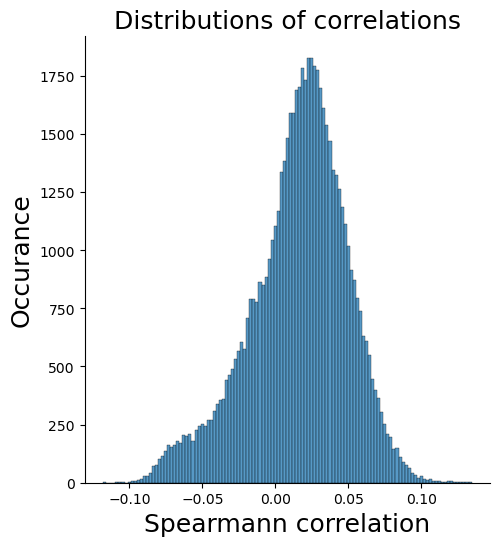

In [72]:
sns.displot(eval_score_list[1])
plt.title('Distributions of correlations', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Spearmann correlation', size=18)
sns.despine()
plt.show()

In [82]:
# lets plot the voxels above the 99th percentile
threshold = np.percentile(eval_score_list[4], 99)
plot_img = new_img_like(tmp_img, RDM_brain_list[4])
cmap = RDMcolormapObject()
coords = range(-100, 100, 5)


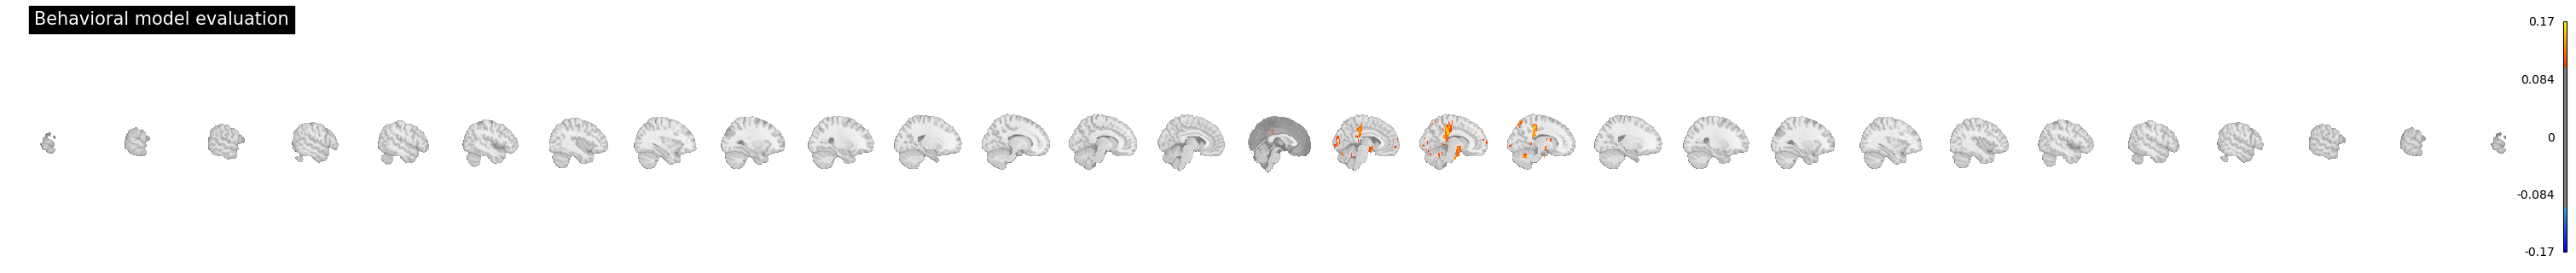

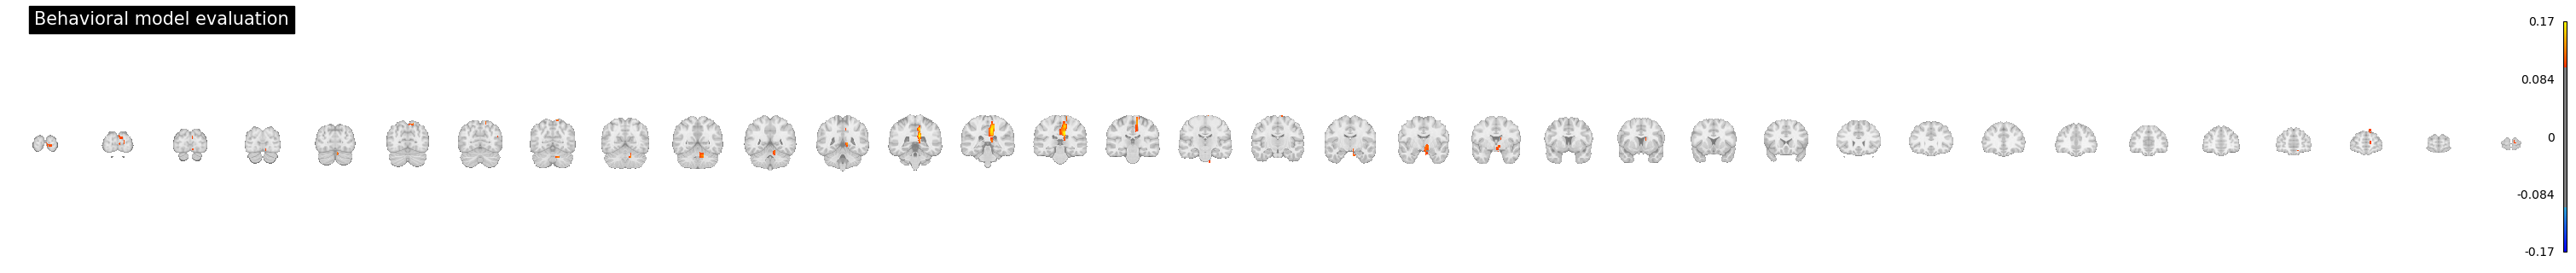

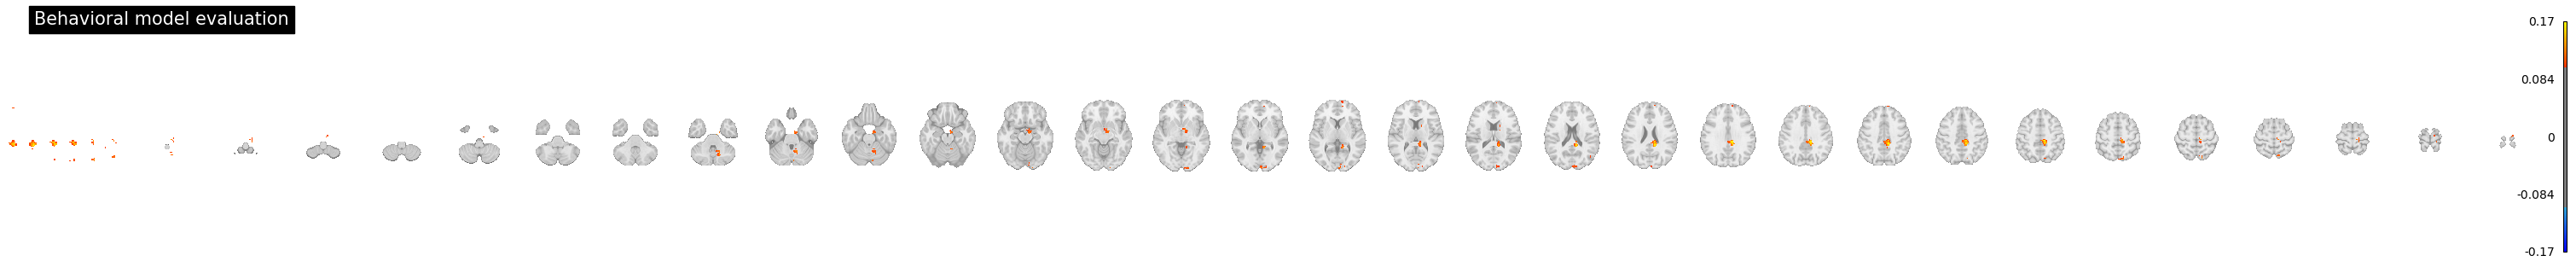

In [83]:
fig_x = plt.figure(figsize=(30, 3))
display_x = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='x', draw_cross=False, figure=fig_x,
        title=f'Behavioral model evaluation', cmap=cmap,
        black_bg=False, annotate=False)

fig_y = plt.figure(figsize=(30, 3))
display_y = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='y', draw_cross=False, figure=fig_y,
        title=f'Behavioral model evaluation', cmap=cmap,
        black_bg=False, annotate=False)

fig_z = plt.figure(figsize=(30, 3))        
display_z = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='z', draw_cross=False, figure=fig_z,
        title=f'Behavioral model evaluation', cmap=cmap,
        black_bg=False, annotate=False)

# # Create new figure and three subplots, sharing axes
# fig3, (ax1, ax2, ax3) = plt.subplots(3,1,sharey=True, sharex=True,figsize=(60,12))        
# fig3.show()
plt.show()

In [87]:
RDM_brain_list[1].shape

(53, 63, 46)

In [95]:
for i in range(20):
    sl_max = np.max(RDM_brain_list[i])
    sl_min = np.min(RDM_brain_list[i])
    print("Subject{} max:{}, min:{}".format(i+1,sl_max,sl_min ))

Subject1 max:0.13915787519280057, min:-0.06218858430394365
Subject2 max:0.13440849133523194, min:-0.11793409705242301
Subject3 max:0.1321737427808339, min:-0.09818724445731741
Subject4 max:0.16367244665776062, min:-0.08549715667516394
Subject5 max:0.16706796866361392, min:-0.09790515685785202
Subject6 max:0.1626816710688151, min:-0.11171336119034868
Subject7 max:0.10983729827936568, min:-0.10728629808431532
Subject8 max:0.11108443510294289, min:-0.08973077322873502
Subject9 max:0.16033882330713445, min:-0.11123742668701668
Subject10 max:0.243272465018756, min:-0.04659402174376555
Subject11 max:0.24433926301125364, min:-0.08415709179846523
Subject12 max:0.2003103381600929, min:-0.1204476784575726
Subject13 max:0.07712720895926518, min:-0.1059034507909291
Subject14 max:0.13755540918541947, min:-0.08717518089487432
Subject15 max:0.11624541374708101, min:-0.09308067681511527
Subject16 max:0.11122361889169184, min:-0.0729178623570409
Subject17 max:0.1254378531262383, min:-0.0682969382807402

In [97]:
RDM_brain_bin_list = []

for i in range(20):
    RDM_brain_bin = np.where(RDM_brain_list[i] > 0.1, 1, 0)
    RDM_brain_bin_list.append(RDM_brain_bin)

In [99]:
for i in range(20):
    sl_max = np.max(RDM_brain_bin_list[i])
    sl_min = np.min(RDM_brain_bin_list[i])
    print("Subject{} max:{}, min:{}".format(i+1,sl_max,sl_min ))

Subject1 max:1, min:0
Subject2 max:1, min:0
Subject3 max:1, min:0
Subject4 max:1, min:0
Subject5 max:1, min:0
Subject6 max:1, min:0
Subject7 max:1, min:0
Subject8 max:1, min:0
Subject9 max:1, min:0
Subject10 max:1, min:0
Subject11 max:1, min:0
Subject12 max:1, min:0
Subject13 max:0, min:0
Subject14 max:1, min:0
Subject15 max:1, min:0
Subject16 max:1, min:0
Subject17 max:1, min:0
Subject18 max:1, min:0
Subject19 max:1, min:0
Subject20 max:0, min:0


In [123]:
RDM_brain_bin_array = np.stack(RDM_brain_bin_list, axis=0)
RDM_brain_bin_array.shape

(20, 53, 63, 46)

In [117]:
SL_threshcount = np.sum(RDM_brain_bin_array, axis = 0)

In [124]:
sl_bin_max = np.max(SL_threshcount)
sl_bin_min = np.min(SL_threshcount)
print("max:{}, min:{}".format(sl_bin_max,sl_bin_min ))

max:5, min:0


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))



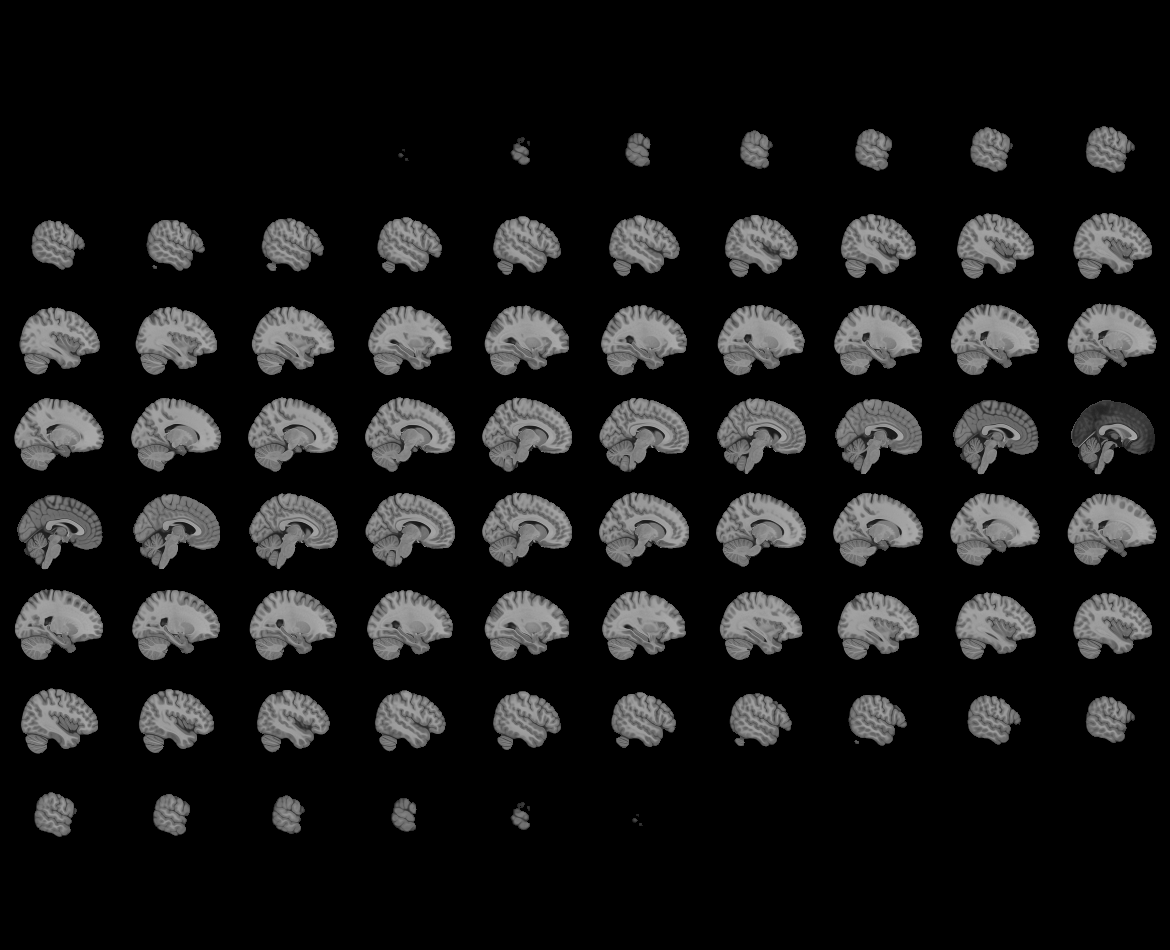
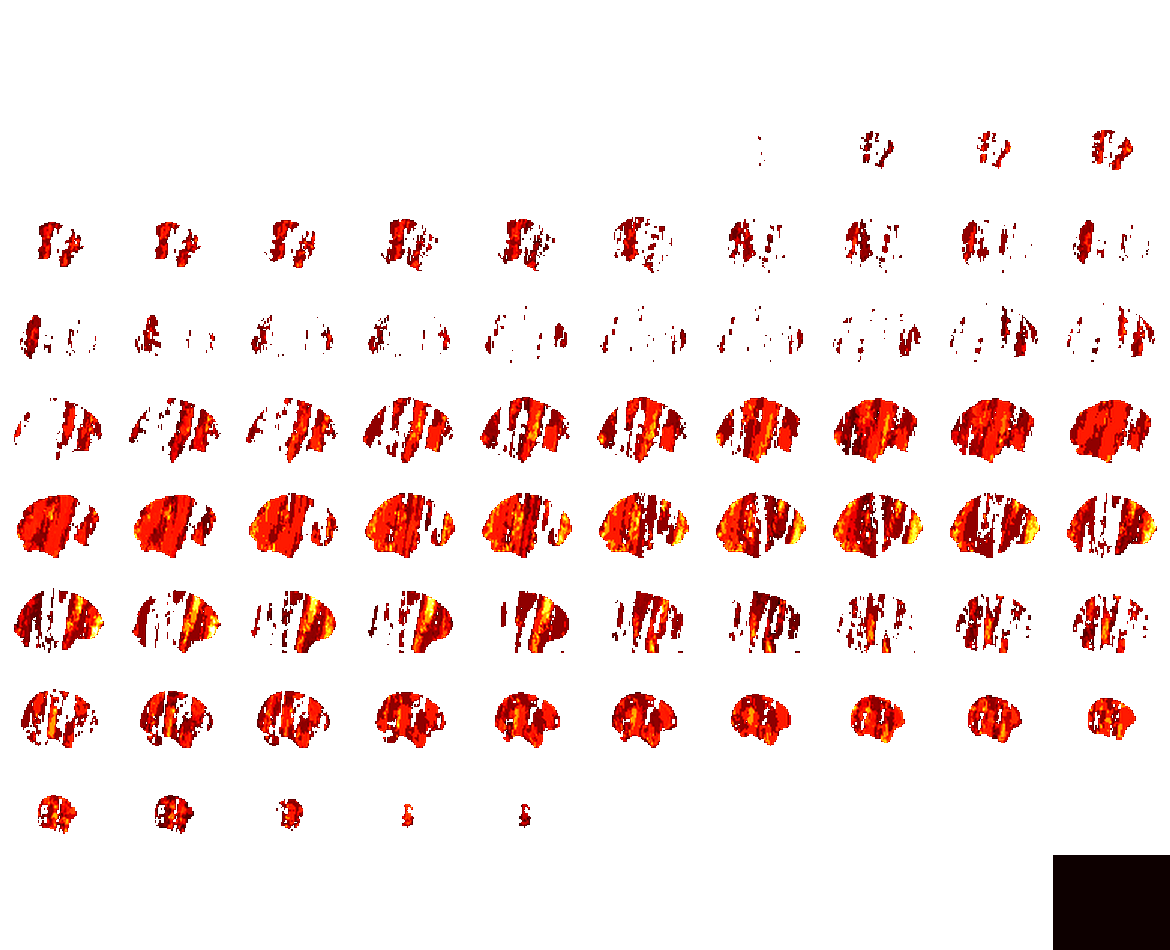

In [126]:
plot_SL_img = new_img_like(tmp_img, SL_threshcount)
view = plotting.view_img(plot_SL_img)
view